<span style="color: #177cff ; font-size: 40px;">Question 1: Sampling and Central Limit Theorom</span>

In this question we're given three distributions: Poi(10), Exp(1/2), Geo(1/5). We'll see about the CLT by experiment and will get some intuition about it.


<span style="color: gold; font-size: 30px;">Part 1: Expectaions and Varicanes of The Distributions</span>

For Poisson distribution with parameter lambda the expectation is equal to lambda(which is n * p actually) and the variance equals lambda too(which is also n * p * (1-p) = n * p.) 

So: If X ~ Poi(10) Then: E[X] = 10 and Var(X) = 10

In exponential distribution, expectation equals 1/lambda and variance is equal to 1/lambda**2. So:

If Y ~ Exp(1/2): Exp[Y] = 2 and Var(Y) = 1 / (1/4) = 4

Also for geometric distribution the expectation is 1/p and the variance is (1-p) / p**2.

If Z ~ geo(1/5): Exp[Z] = 5 and Var(Z) = (1 - 1/5) / (1/25) = 20

<span style="color: gold; font-size: 30px;">Part 2: Sampling and Plotting Means</span>

First I have my samples ready and calculate their means in-place by Numpy built-in functions.

<span style="color: red; font-size: 20px;">Note: </span>For exponential distribution sampling np.random.exponential() function takes the scale parameter which is equal to the expectation of the distribution that is 1 / (1/2) = 2.

In [ ]:
import numpy as np

num_of_samplings = 1000
poi = {
    30: np.random.poisson(lam = 10, size = (num_of_samplings, 30)).mean(axis = 1),
    300: np.random.poisson(lam = 10, size = (num_of_samplings, 300)).mean(axis = 1),
    3000: np.random.poisson(lam = 10, size = (num_of_samplings, 3000)).mean(axis = 1)
}

exp = {
    30: np.random.exponential(scale = 2, size = (num_of_samplings, 30)).mean(axis = 1),
    300: np.random.exponential(scale = 2, size = (num_of_samplings, 300)).mean(axis = 1),
    3000: np.random.exponential(scale = 2, size = (num_of_samplings, 3000)).mean(axis = 1)
}

geo = {
    30: np.random.geometric(p = 1/5, size = (num_of_samplings, 30)).mean(axis = 1),
    300: np.random.geometric(p = 1/5, size = (num_of_samplings, 300)).mean(axis = 1),
    3000: np.random.geometric(p = 1/5, size = (num_of_samplings, 3000)).mean(axis = 1)
}

Then I plot the data by hisograms in matplotlib. 

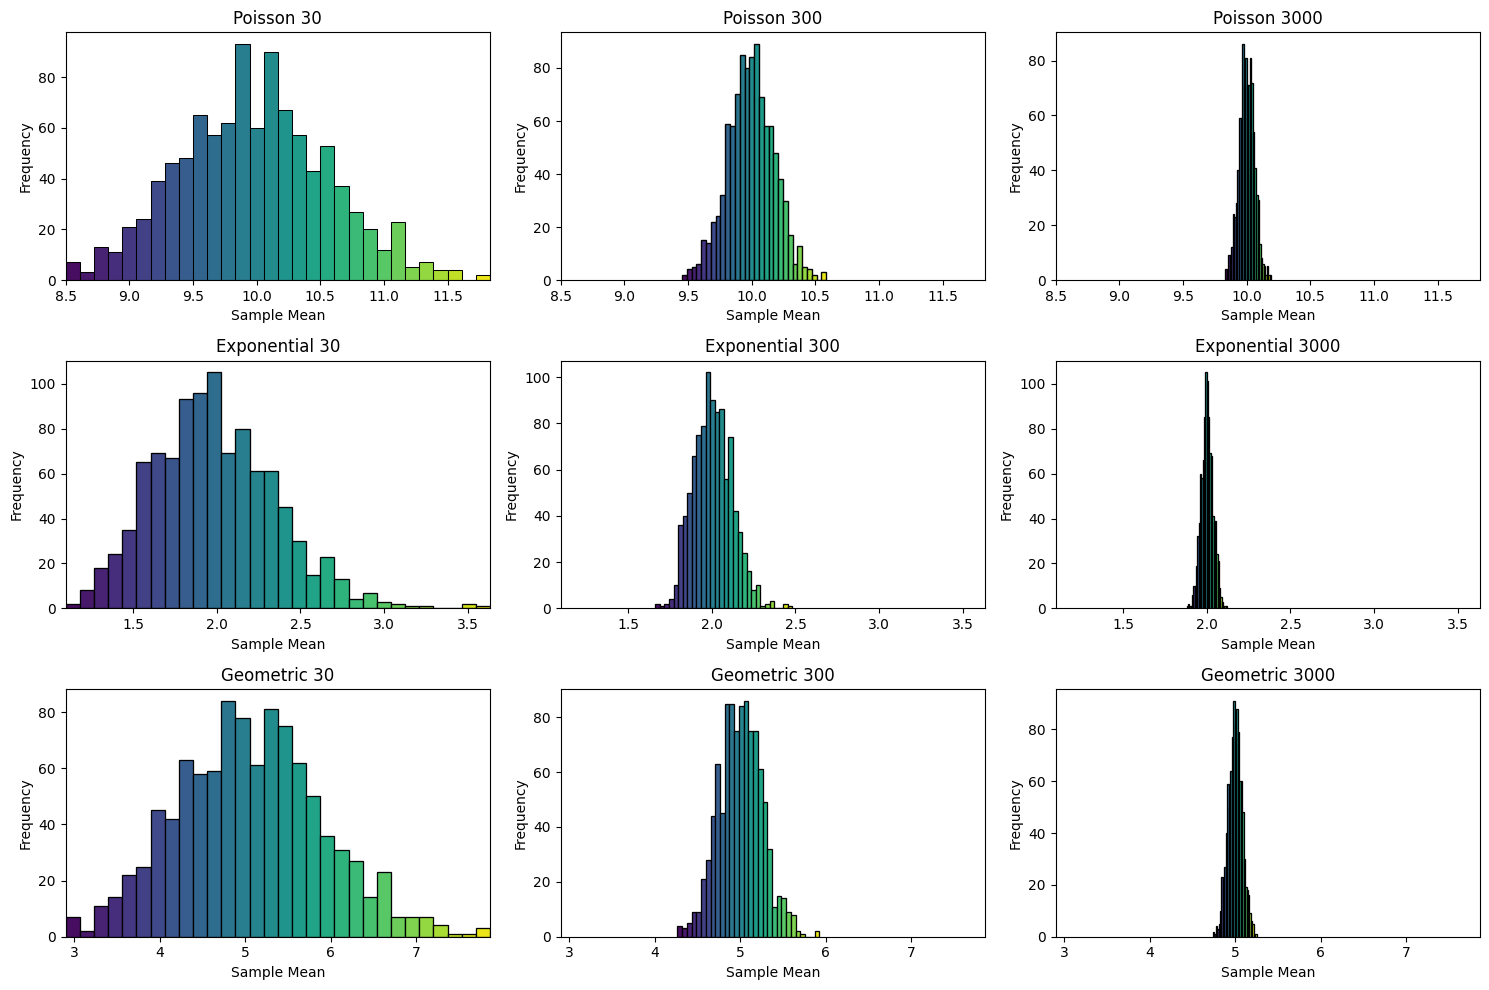

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (15, 10))

min_val_poi = min(poi[30].min(), poi[300].min(), poi[3000].min())
max_val_poi = max(poi[30].max(), poi[300].max(), poi[3000].max())
min_val_exp = min(exp[30].min(), exp[300].min(), exp[3000].min())
max_val_exp = max(exp[30].max(), exp[300].max(), exp[3000].max())
min_val_geo = min(geo[30].min(), geo[300].min(), geo[3000].min())
max_val_geo = max(geo[30].max(), geo[300].max(), geo[3000].max())

x_limits_poi = (min_val_poi, max_val_poi)
x_limits_exp = (min_val_exp, max_val_exp)
x_limits_geo = (min_val_geo, max_val_geo)

cm = sns.color_palette("viridis", 30) #Beautiful color combination:)

for i, n in enumerate(poi):
    plt.subplot(3, 3, i + 1)
    plot = sns.histplot(poi[n], bins = 30)
    
    for bin_,i in zip(plot.patches,cm):
        bin_.set_facecolor(i)
        
    plt.title("Poisson " + str(n))
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.xlim(x_limits_poi)
    plt.tight_layout()
    
for i, n in enumerate(exp):
    plt.subplot(3, 3, i + 4)
    plot = sns.histplot(exp[n], bins = 30) 
       
    for bin_,i in zip(plot.patches,cm):
        bin_.set_facecolor(i)
        
    plt.title("Exponential " + str(n))
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.xlim(x_limits_exp)
    plt.tight_layout()
    
for i, n in enumerate(geo):
    plt.subplot(3, 3, i + 7)
    plot = sns.histplot(geo[n], bins = 30)
        
    for bin_,i in zip(plot.patches,cm):
        bin_.set_facecolor(i)
        
    plt.title("Geometric " + str(n))
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.xlim(x_limits_geo)
    plt.tight_layout()
    
plt.show()


<span style="color: gold; font-size: 30px;">Part 3: Analysing Mean and Std of Samplings</span>

I'll simply compose some Numpy functions and print the means and stds of the samplings.

In [ ]:
print("***************************************   Poisson   ***************************************")
print("Actual mean: ", 10)
print(f"Actual std: {10 ** (1/2):.5f}")
print(f"The mean of mean of 1000 Poisson samplings when sample size = 30 is equal to: {np.mean(poi[30]):.5f}")
print(f"The std of mean of 1000 Poisson samplings when sample size = 30 is equal to: {np.std(poi[30]):.5f}")
print(f"The mean of mean of 1000 Poisson samplings when sample size = 300 is equal to: {np.mean(poi[300]):.5f}")
print(f"The std of mean of 1000 Poisson samplings when sample size = 300 is equal to: {np.std(poi[300]):.5f}")
print(f"The mean of mean of 1000 Poisson samplings when sample size = 3000 is equal to: {np.mean(poi[3000]):.5f}")
print(f"The std of mean of 1000 Poisson samplings when sample size = 3000 is equal to: {np.std(poi[3000]):.5f}")

print("\n***********************************   Exponential   ***************************************")
print(f"Actual mean: {2}")
print(f"Actual std: {2}")
print(f"The mean of mean of 1000 Exponential samplings when sample size = 30 is equal to: {np.mean(exp[30]):.5f}")
print(f"The std of mean of 1000 Exponential samplings when sample size = 30 is equal to: {np.std(exp[30]):.5f}")
print(f"The mean of mean of 1000 Exponential samplings when sample size = 300 is equal to: {np.mean(exp[300]):.5f}")
print(f"The std of mean of 1000 Exponential samplings when sample size = 300 is equal to: {np.std(exp[300]):.5f}")
print(f"The mean of mean of 1000 Exponential samplings when sample size = 3000 is equal to: {np.mean(exp[3000]):.5f}")
print(f"The std of mean of 1000 Exponential samplings when sample size = 3000 is equal to: {np.std(exp[3000]):.5f}")

print("\n*************************************   Geometric   ***************************************")
print(f"Actual mean: {5}")
print(f"Actual std: {20 ** (1/2):.5f}")
print(f"The mean of mean of 1000 Geometric samplings when sample size = 30 is equal to: {np.mean(geo[30]):.5f}")
print(f"The std of mean of 1000 Geometric samplings when sample size = 30 is equal to: {np.std(geo[30]):.5f}")
print(f"The mean of mean of 1000 Geometric samplings when sample size = 300 is equal to: {np.mean(geo[300]):.5f}")
print(f"The std of mean of 1000 Geometric samplings when sample size = 300 is equal to: {np.std(geo[300]):.5f}")
print(f"The mean of mean of 1000 Geometric samplings when sample size = 3000 is equal to: {np.mean(geo[3000]):.5f}")
print(f"The std of mean of 1000 Geometric samplings when sample size = 3000 is equal to: {np.std(geo[3000]):.5f}")


***************************************   Poisson   ***************************************
Actual mean:  10
Actual std: 3.16228
The mean of mean of 1000 Poisson samplings when sample size = 30 is equal to: 10.01557
The std of mean of 1000 Poisson samplings when sample size = 30 is equal to: 0.57042
The mean of mean of 1000 Poisson samplings when sample size = 300 is equal to: 9.99367
The std of mean of 1000 Poisson samplings when sample size = 300 is equal to: 0.18540
The mean of mean of 1000 Poisson samplings when sample size = 3000 is equal to: 9.99904
The std of mean of 1000 Poisson samplings when sample size = 3000 is equal to: 0.05912

***********************************   Exponential   ***************************************
Actual mean: 2
Actual std: 2
The mean of mean of 1000 Exponential samplings when sample size = 30 is equal to: 2.01186
The std of mean of 1000 Exponential samplings when sample size = 30 is equal to: 0.36914
The mean of mean of 1000 Exponential samplings whe

As we can see, the more sample size we dedicate the better estimation we'll have for the mean of population and the less varicance and std we'll have for the means(because the variance of a mean of a sampling is σ^2/n.)

<span style="color: gold; font-size: 30px;">Part 4: Adding Normal Distributions to The Plots And Aanalysing Them</span>

For this part we need the pdf function for normal distribution. So I import the norm distributionfrom scipy library. I'll have to plot all the plots again in three loops adding the noraml distribution to them.

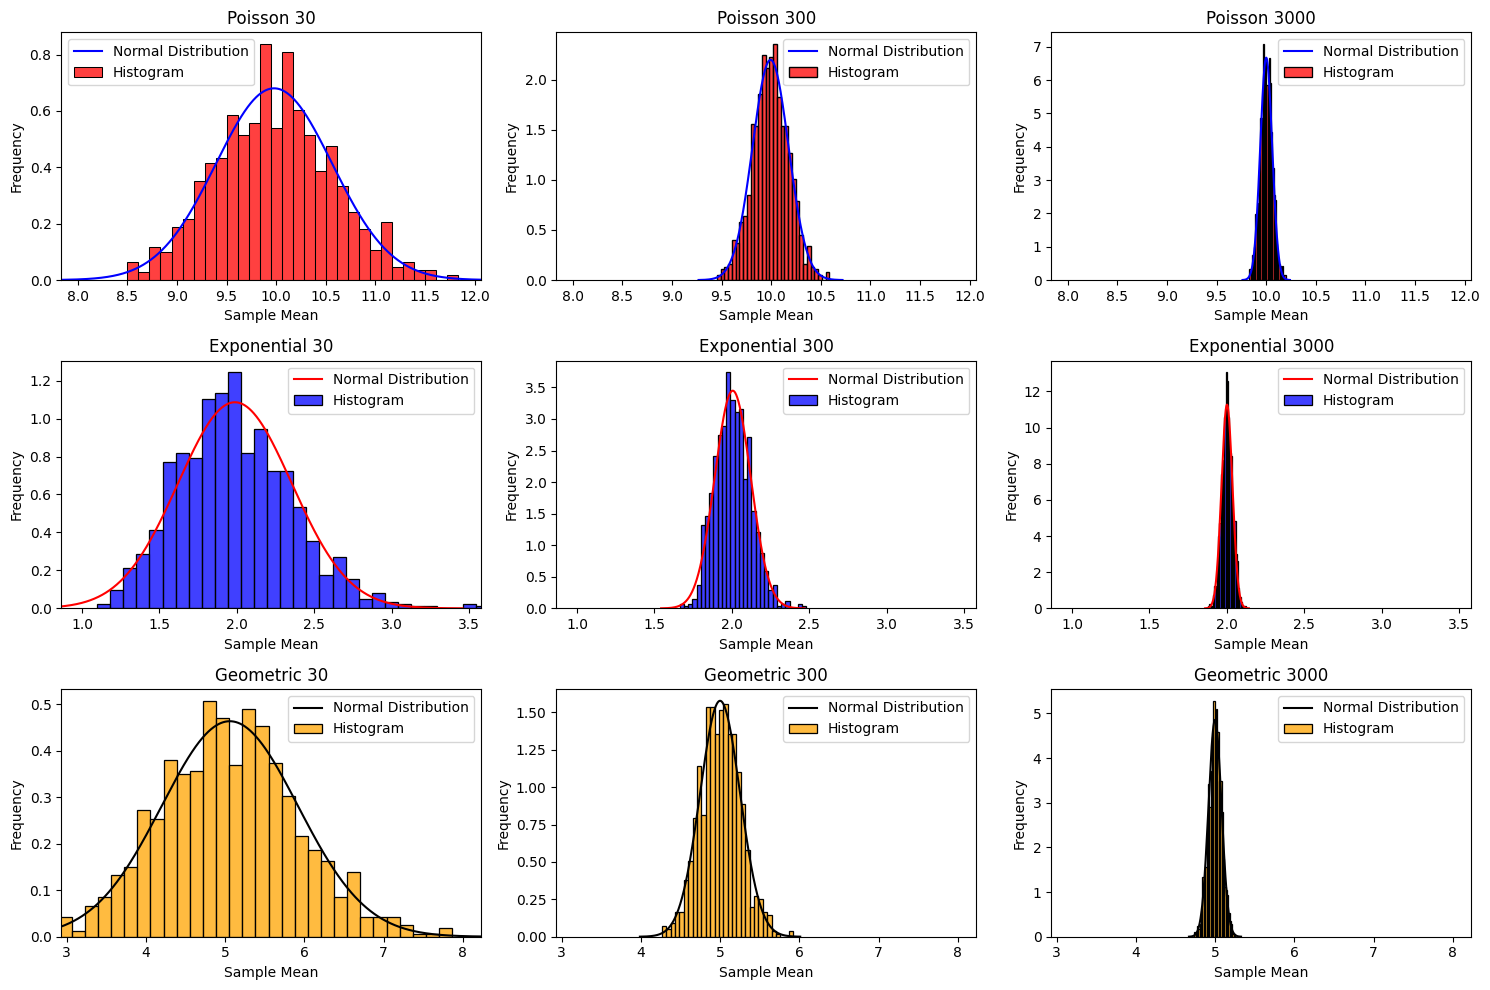

In [85]:
from scipy.stats import norm

plt.figure(figsize = (15, 10))
for i, n in enumerate(poi):
    plt.subplot(3, 3, i + 1)
    sns.histplot(poi[n], bins = 30, color = "red", stat = "density", label = "Histogram")
    plt.title("Poisson " + str(n))
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    mean = np.mean(poi[n])
    std = np.std(poi[n])
    x = np.linspace(mean - 4 * std, mean + 4 * std, 1000)
    plt.plot(x, norm.pdf(x, mean, std), color = 'blue', label = "Normal Distribution")
    plt.xlim(x_limits_poi)
    plt.tight_layout()
    plt.legend()
    
for i, n in enumerate(exp):
    plt.subplot(3, 3, i + 4)
    sns.histplot(exp[n], bins = 30, color = "blue", stat = "density", label = "Histogram")
    plt.title("Exponential " + str(n))
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    mean = np.mean(exp[n])
    std = np.std(exp[n])
    x = np.linspace(mean - 4 * std, mean + 4 * std, 1000)
    plt.plot(x, norm.pdf(x, mean, std), color = 'red', label = "Normal Distribution")
    plt.xlim(x_limits_exp)
    plt.tight_layout()
    plt.legend()
    
for i, n in enumerate(geo):
    plt.subplot(3, 3, i + 7)
    sns.histplot(geo[n], bins = 30, color = "orange", stat = "density", label = "Histogram")
    plt.title("Geometric " + str(n))
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    mean = np.mean(geo[n])
    std = np.std(geo[n])
    x = np.linspace(mean - 4 * std, mean + 4 * std, 1000)
    plt.plot(x, norm.pdf(x, mean, std), color = 'black', label = "Normal Distribution")
    plt.xlim(x_limits_geo)
    plt.tight_layout()
    plt.legend()
    
plt.show()


As we can see, the distribution of sample means looks more and more like the normal distribution as we increase n(the number of samples.) This is because of the CLT(Central Limit Theory) which says the more n approaches infinity the more exact estimation is the normal distribution of sum of some i.i.d RVs(which is divided by n here and is corresponding to the sample mean.)

<span style="color: gold; font-size: 30px;">Part 5: Choosing Distributions Randomly And Evaluating The Samplings</span>

In this part I will randomly(with uniformly distributed probability) choose one of the three distributions and get n samples of that. I'll do this in a loop with 1000 iteration, then I'll create the sample mean list for all the samplings and try to guess their distribution by plotting them.

In [ ]:
means = {
            30: np.zeros(shape = num_of_samplings),
            300: np.zeros(shape = num_of_samplings), 
            3000: np.zeros(shape = num_of_samplings)
        }

for n in means:
    for i in range(num_of_samplings):
        dist_num = np.random.randint(3)
        if dist_num == 0:
            means[n][i] = np.random.poisson(lam = 10, size = n).mean(axis = 0)
        elif dist_num == 1:
            means[n][i] = np.random.exponential(scale = 2, size = n).mean()
        else:
            means[n][i] = np.random.geometric(p = 1/5, size = n).mean()

Now I'll plot them:

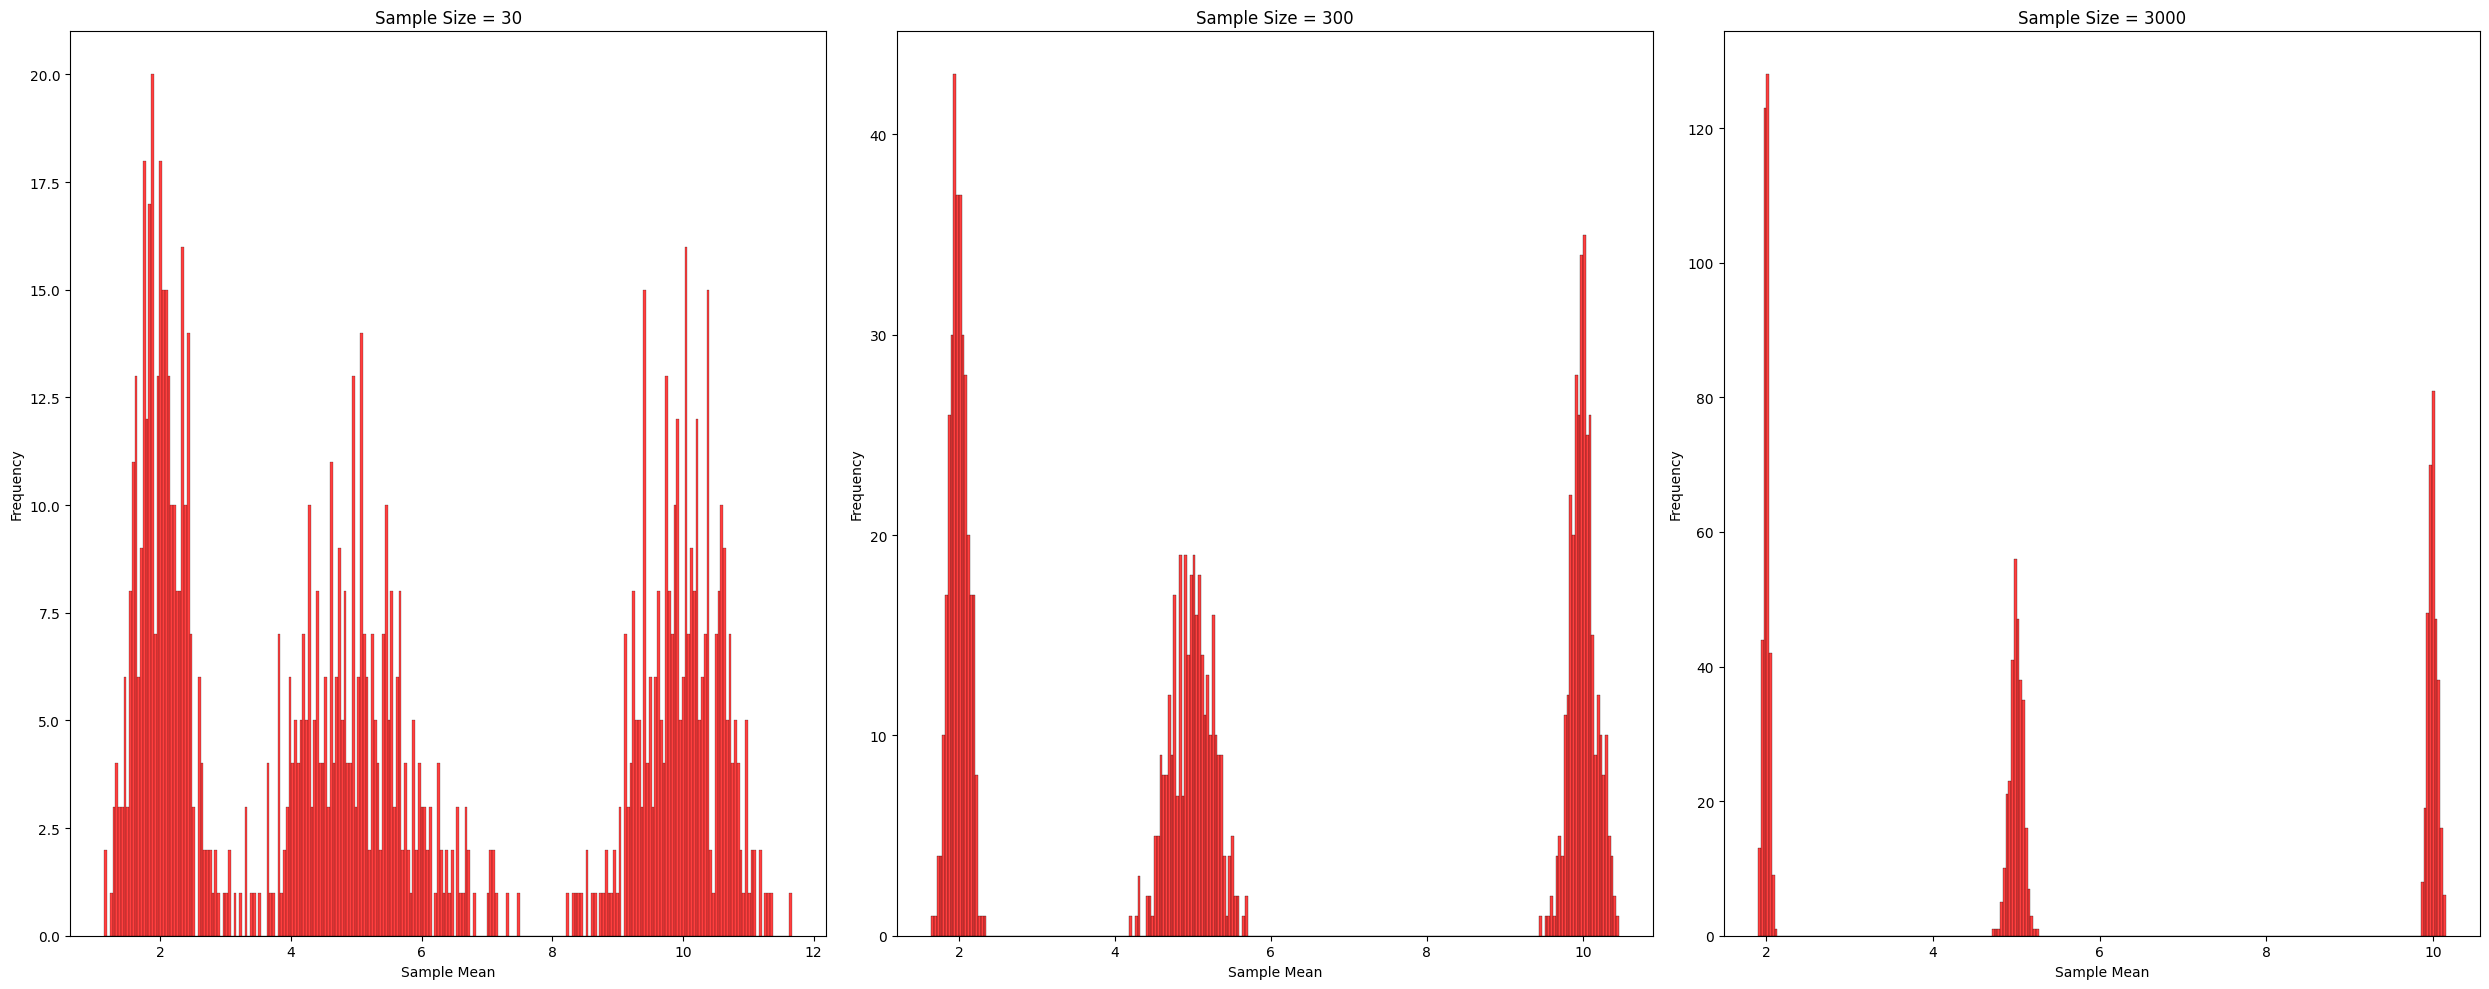

In [120]:
plt.figure(figsize = (25, 10))

for i, n in enumerate(means):
    plt.subplot(1, 3, i + 1)
    plot = sns.histplot(means[n], bins = 250, color = "red")
    plt.title("Sample Size = " + str(n))
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.tight_layout()
    
plt.show()

For each sample size three noraml distributions get made by the data. For bigger sample sizes the normal distributions are thinner and sharper peaking arround their mean. 

Now I'll report their mean and std:

In [119]:
print("The mean for distribution when sample size = 30 is: ", means[30].mean())
print("The std for distribution when sample size = 30 is: ", means[30].std())

print("The mean for distribution when sample size = 300 is: ", means[300].mean())
print("The std for distribution when sample size = 300 is: ", means[300].std())

print("The mean for distribution when sample size = 3000 is: ", means[3000].mean())
print("The std for distribution when sample size = 3000 is: ", means[3000].std())

The mean for distribution when sample size = 30 is:  5.686295771955482
The std for distribution when sample size = 30 is:  3.338172584266237
The mean for distribution when sample size = 300 is:  5.6662216790952735
The std for distribution when sample size = 300 is:  3.309276328936072
The mean for distribution when sample size = 3000 is:  5.583761600517301
The std for distribution when sample size = 3000 is:  3.348685392995884


<span style="color: gold; font-size: 30px;">Part 6: Calculating The Mean and Std Before Sampling</span>

The answer to this question is "No." Because the varibales are chosen randomly with probability of 1/3, so they ain't i.i.d and we cant calculate the mean and variance by only knowing the prior distributions.

<span style="color: gold; font-size: 30px;">Part 7: Multivariable Normal Distribution</span>

First, I plot the normal distribution for part 5.

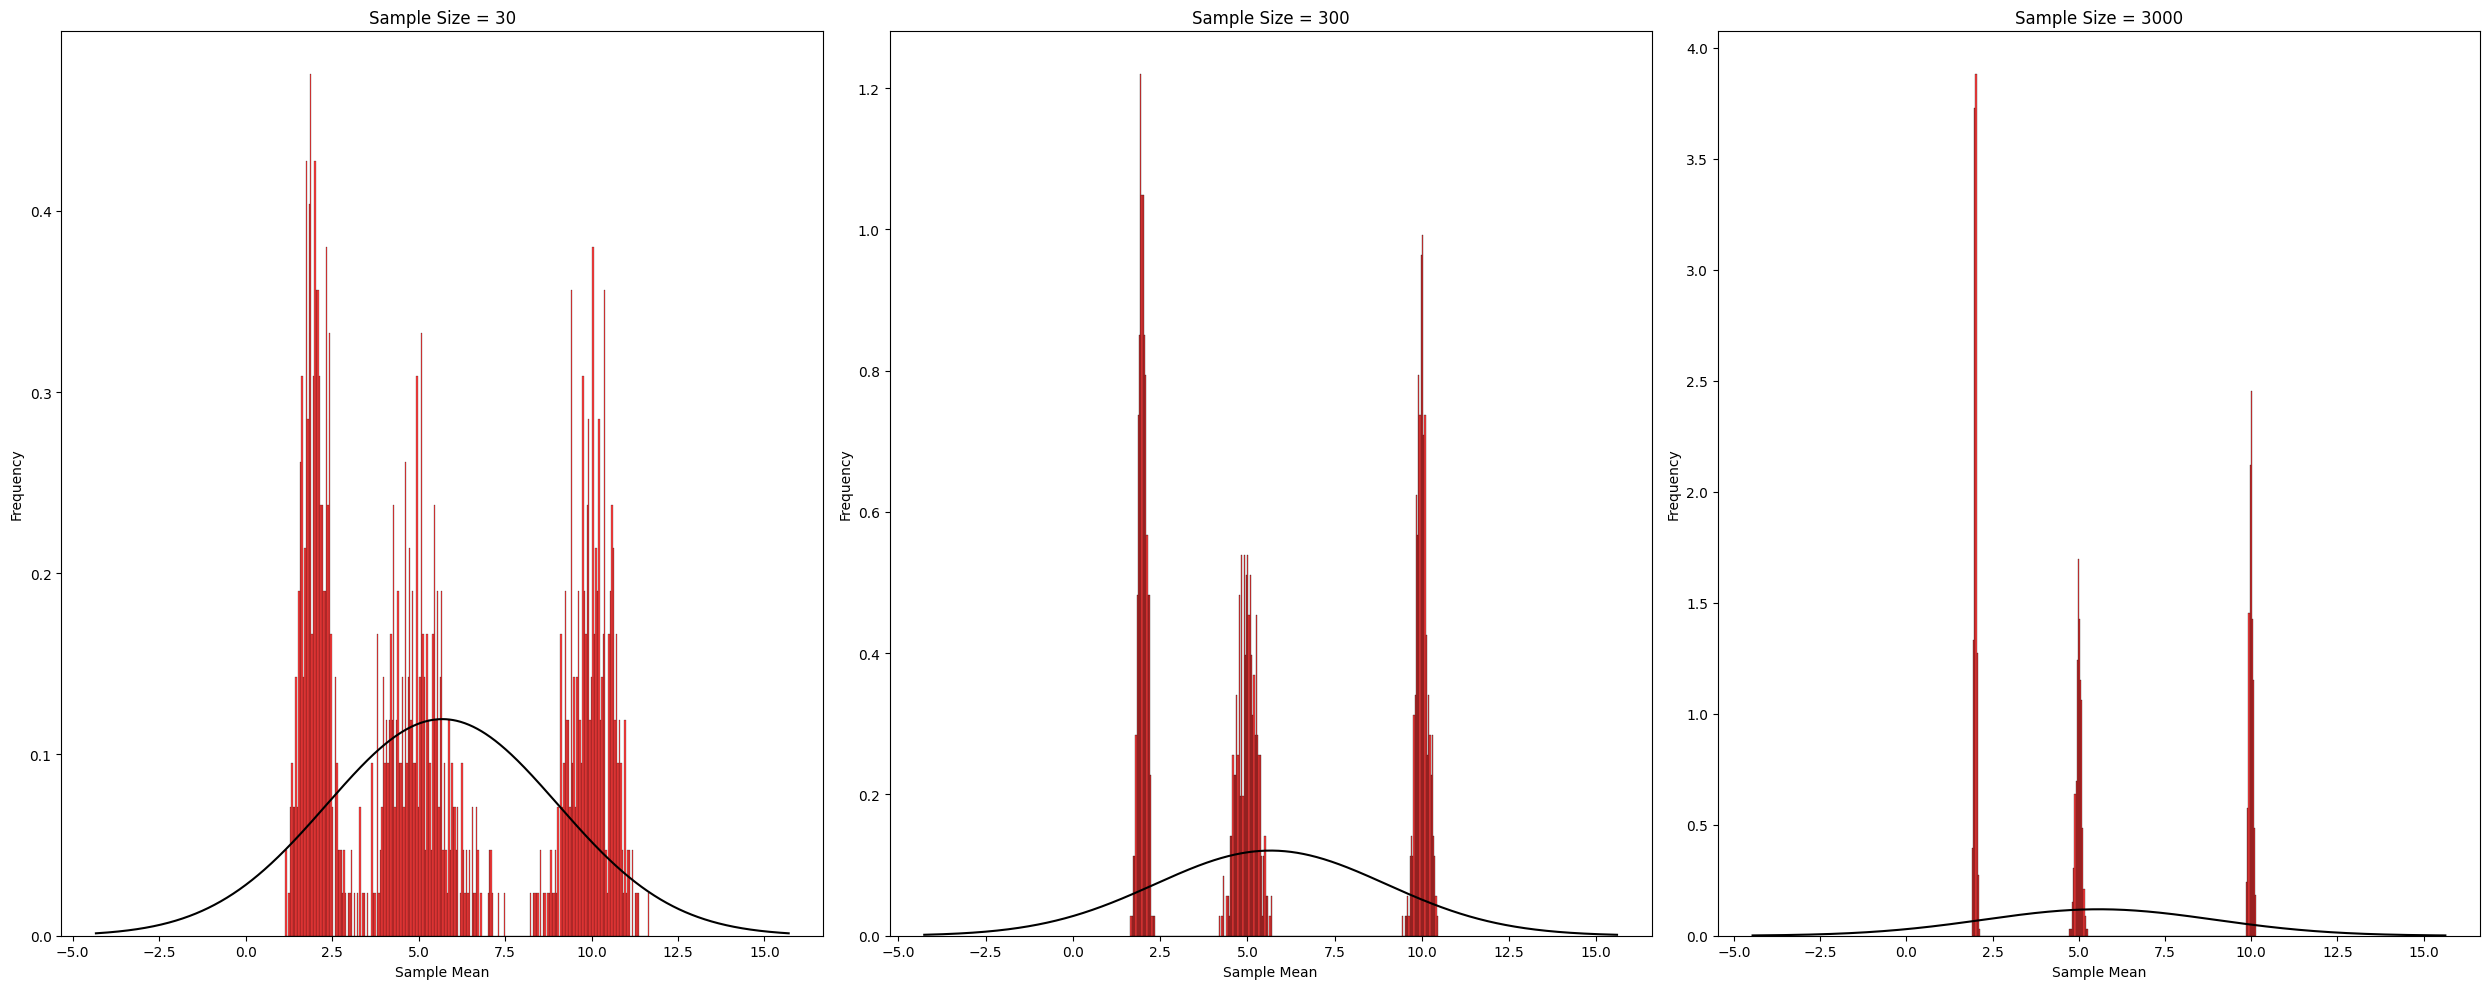

In [126]:
plt.figure(figsize = (25, 10))

for i, n in enumerate(means):
    plt.subplot(1, 3, i + 1)
    plot = sns.histplot(means[n], bins = 250, color = "red", stat = "density")
    plt.title("Sample Size = " + str(n))
    mean = np.mean(means[n])
    std = np.std(means[n])
    x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)
    plt.plot(x, norm.pdf(x, mean, std), color = 'black', label = "Normal Distribution")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.tight_layout()
    
plt.show()

I suppose the distributions of part 4 are jointly normal. Because according to the CLT we know each of those 9 distributions is a normal distribution(knowing that n >= 30.) And Because all of the prior variables, Xi and Yi and Zi, are independent from the others so the 9 distributions(which each is a normal distribution) are independent from the others. So they are jointly normal distributed; because we know that sum of some random variables from different independent normal distributions is a multivariable normal(jointly normal) distribution.